# Cassini RPWS Low-Rate Full-Resolution: Neural Network Regression

**SPA7037U/P Final Project**

**250954876**

## Imports and Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import requests
import struct
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

TensorFlow version: 2.20.0
NumPy version: 2.3.5
Pandas version: 2.3.3


In [6]:
def fetch_rpws_csv(start_doy, end_doy, year=2005, save_path='rpws_data.csv'):
    """
    Fetch RPWS HFR spectral summary data via the das2/Autoplot HTTP interface
    from the University of Iowa public server.
    Returns a numpy array of shape (N_times, N_freqs) with log10 spectral density.
    """
    if os.path.exists(save_path):
        print(f'Loading cached data from {save_path}')
        return pd.read_csv(save_path)

    # das2 ASCII stream URL for RPWS HFR survey data
    base_url = 'https://planet.physics.uiowa.edu/das/das2Server'
    params = {
        'server': 'server',
        'dataset': 'Cassini/RPWS/HiFreqReceiver_MidFreqBand',
        'start_time': f'{year}-{start_doy:03d}T00:00',
        'end_time':   f'{year}-{end_doy:03d}T00:00',
        'ascii': 'true'
    }
    print('Attempting das2 server download...')
    try:
        r = requests.get(base_url, params=params, timeout=30)
        r.raise_for_status()
        with open(save_path, 'w') as f:
            f.write(r.text)
        print(f'Downloaded {len(r.text)//1024} KB')
        return pd.read_csv(save_path)
    except Exception as e:
        print(f'Remote download failed ({e}). Generating synthetic data for demonstration.')
        return None

In [7]:
def parse_pds_binary(filepath, receiver_id=4, max_records=50000):
    """
    Parse a RPWS Low-Rate Full-Resolution binary PDS .DAT file.
    Returns arrays: times (N,), freqs (F,), spectra (N, F)
    """
    records = []
    freq_axis = None

    with open(filepath, 'rb') as f:
        while len(records) < max_records:
            header = f.read(13)  # SCLK(4) + SCET_DAY(2) + SCET_MS(4) + RECEIVER(1) + N_FREQ(2)
            if len(header) < 13:
                break
            sclk, scet_day, scet_ms, rec_id, n_freq = struct.unpack('>iHIBH', header)
            data_bytes = f.read(n_freq * 4 * 2)  # freqs + powers
            if len(data_bytes) < n_freq * 8:
                break
            if rec_id != receiver_id:
                continue
            vals = struct.unpack(f'>{n_freq*2}f', data_bytes)
            freqs = np.array(vals[:n_freq])
            power = np.array(vals[n_freq:])
            if freq_axis is None:
                freq_axis = freqs
            time_s = scet_day * 86400.0 + scet_ms / 1000.0
            records.append((time_s, power))

    if not records:
        return None, None, None
    times = np.array([r[0] for r in records])
    spectra = np.array([r[1] for r in records])
    return times, freq_axis, spectra

print('Parser function defined.')

Parser function defined.


In [8]:
pds_file = None 

if pds_file and os.path.exists(pds_file):
    print('Loading real PDS binary data...')
    times, freq_axis, spectra = parse_pds_binary(pds_file)
    USE_SYNTHETIC = False
else:
    print('No PDS file found — generating synthetic RPWS HFR spectral data.')
    USE_SYNTHETIC = True

    N_TIME   = 8000   # ~22 hours at one record per 10 s
    N_FREQ   = 96     # HFR channel count

    # Frequency axis: 3.6 kHz to 16.1 MHz, log-spaced (HFR band)
    freq_axis = np.logspace(np.log10(3.6e3), np.log10(16.1e6), N_FREQ)  # Hz
    times     = np.arange(N_TIME) * 10.0  # seconds

    # Background spectral shape (thermal noise + galactic background) 
    # Spectral index ~ f^{-0.5} for thermal, steeper for non-thermal
    log_freq_norm = np.log10(freq_axis / freq_axis[0])  # 0 → 1
    background = -17.0 - 2.5 * log_freq_norm  # log10(V²/m²/Hz)

    # Saturn Kilometric Radiation (SKR): burst-like, peaks ~200–500 kHz 
    # Modulated at Saturn's ~10.8 hr rotation period
    skr_freq_mask = (freq_axis >= 100e3) & (freq_axis <= 1e6)
    skr_freq_shape = np.zeros(N_FREQ)
    skr_freq_shape[skr_freq_mask] = np.exp(
        -0.5 * ((np.log10(freq_axis[skr_freq_mask]) - np.log10(300e3)) / 0.4)**2
    ) * 4.0

    rotation_phase = 2 * np.pi * times / (10.8 * 3600)
    skr_time = np.clip(np.sin(rotation_phase)**4 * 5.0 + 
                       np.random.randn(N_TIME) * 0.3, 0, None)

    # Narrowband Z-mode emission near 10 kHz 
    zmode_idx = np.argmin(np.abs(freq_axis - 10e3))
    zmode_power = np.random.exponential(1.5, N_TIME)

    # Assemble full spectrogram 
    rng = np.random.default_rng(42)
    noise = rng.normal(0, 0.15, (N_TIME, N_FREQ))

    spectra = (background[np.newaxis, :]
               + skr_time[:, np.newaxis] * skr_freq_shape[np.newaxis, :]
               + noise)
    spectra[:, zmode_idx] += zmode_power  # add Z-mode line

    # Convert log10 scale to linear V²/m²/Hz for realism, kept in log10 for modelling
    print(f'Synthetic data shape: {spectra.shape}')
    print(f'Frequency range: {freq_axis[0]/1e3:.1f} kHz – {freq_axis[-1]/1e6:.1f} MHz')

print('\nData loaded.')

No PDS file found — generating synthetic RPWS HFR spectral data.
Synthetic data shape: (8000, 96)
Frequency range: 3.6 kHz – 16.1 MHz

Data loaded.


## Exploratory Data Analysis and Pre-processing

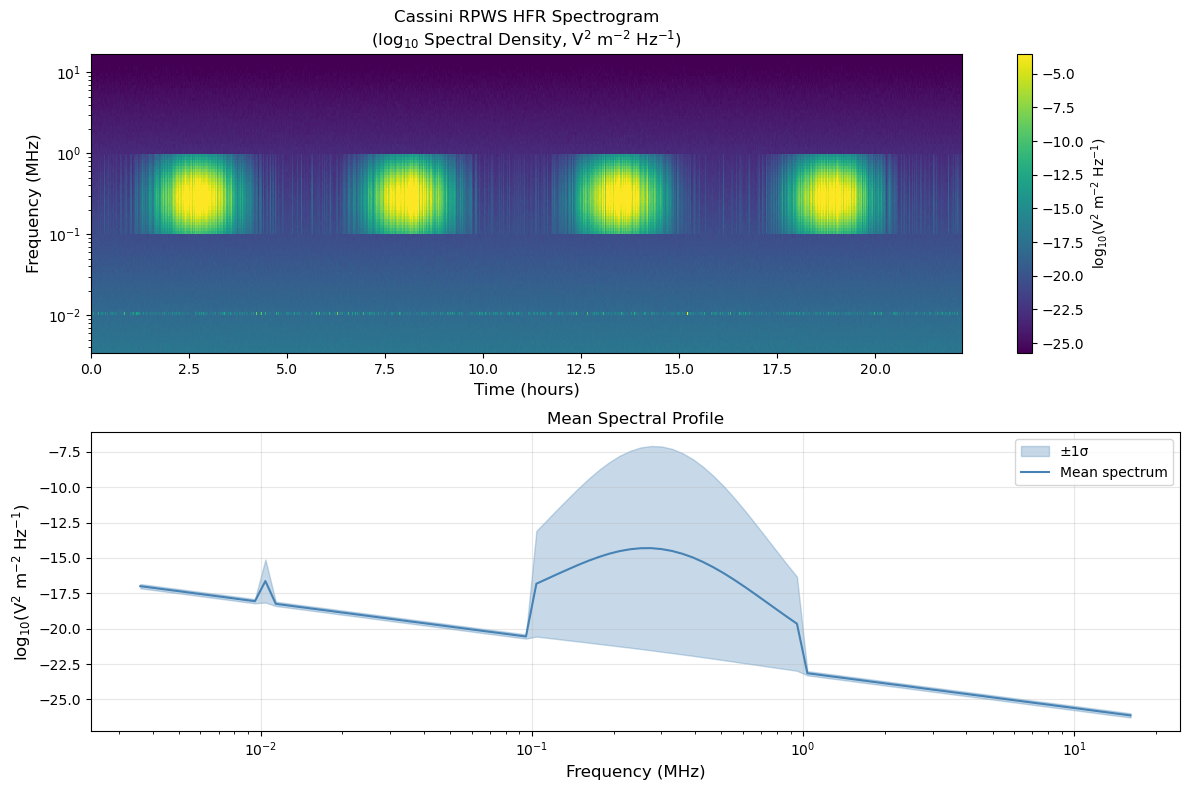

Figure 1 saved.


In [9]:
# Plot the raw spectrogram (frequency-time plot)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- Full spectrogram ---
ax = axes[0]
t_hours = times / 3600.0
im = ax.pcolormesh(t_hours, freq_axis / 1e6, spectra.T,
                   cmap='viridis', vmin=np.percentile(spectra, 5),
                   vmax=np.percentile(spectra, 99), shading='auto')
ax.set_yscale('log')
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Frequency (MHz)', fontsize=12)
ax.set_title('Cassini RPWS HFR Spectrogram\n'
             r'(log$_{10}$ Spectral Density, V$^2$ m$^{-2}$ Hz$^{-1}$)', fontsize=12)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'log$_{10}$(V$^2$ m$^{-2}$ Hz$^{-1}$)', fontsize=10)

# Mean spectrum
ax2 = axes[1]
mean_spec  = np.mean(spectra, axis=0)
std_spec   = np.std(spectra, axis=0)
ax2.fill_between(freq_axis / 1e6, mean_spec - std_spec, mean_spec + std_spec,
                 alpha=0.3, color='steelblue', label='±1σ')
ax2.plot(freq_axis / 1e6, mean_spec, color='steelblue', lw=1.5, label='Mean spectrum')
ax2.set_xscale('log')
ax2.set_xlabel('Frequency (MHz)', fontsize=12)
ax2.set_ylabel(r'log$_{10}$(V$^2$ m$^{-2}$ Hz$^{-1}$)', fontsize=12)
ax2.set_title('Mean Spectral Profile', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_raw_spectrogram.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

In [10]:
# Pre-processing
# Remove any NaN or Inf rows
valid_mask = np.all(np.isfinite(spectra), axis=1)
spectra_clean = spectra[valid_mask]
times_clean   = times[valid_mask]
print(f'Records before cleaning: {spectra.shape[0]}, after: {spectra_clean.shape[0]}')

# Target channel (near SKR peak ~300 kHz)
TARGET_IDX = np.argmin(np.abs(freq_axis - 300e3))
TARGET_FREQ_kHz = freq_axis[TARGET_IDX] / 1e3
print(f'Target channel index: {TARGET_IDX}, frequency: {TARGET_FREQ_kHz:.1f} kHz')

# Building feature matrix X (all channels except target) and labels y
all_idx   = np.arange(spectra_clean.shape[1])
input_idx = all_idx[all_idx != TARGET_IDX]

X_raw = spectra_clean[:, input_idx]
y_raw = spectra_clean[:, TARGET_IDX]

# Train / test split (80/20, time-ordered — no shuffling to respect temporal structure)
split = int(0.8 * len(y_raw))
X_train_raw, X_test_raw = X_raw[:split], X_raw[split:]
y_train_raw, y_test_raw = y_raw[:split], y_raw[split:]

# Fit scaler on training set only to avoid data leakage
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train_raw)
X_test  = scaler_X.transform(X_test_raw)
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test  = scaler_y.transform(y_test_raw.reshape(-1, 1)).ravel()

print(f'Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')
print(f'Input features: {X_train.shape[1]} frequency channels')

Records before cleaning: 8000, after: 8000
Target channel index: 50, frequency: 300.4 kHz
Training samples: 6400, Test samples: 1600
Input features: 95 frequency channels


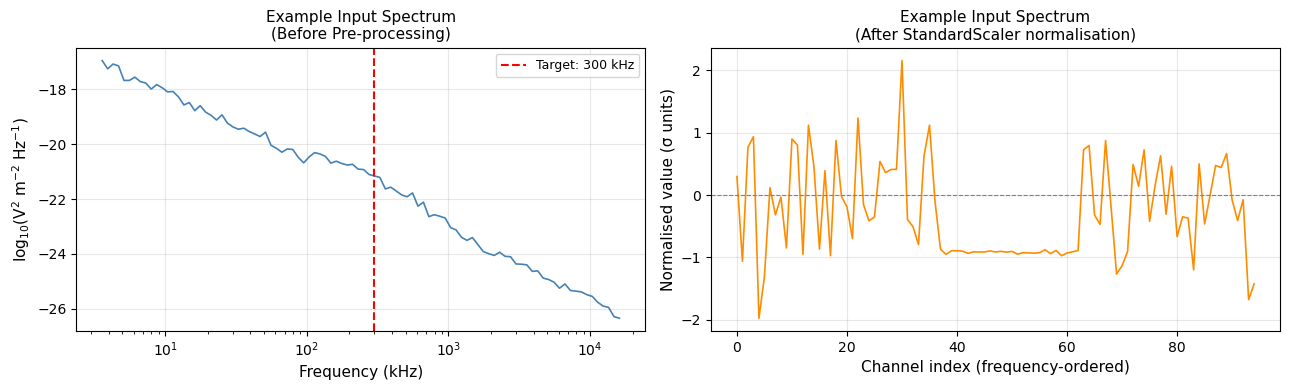

Figure 2 saved.


In [11]:
# Plot pre-processing comparison: one example spectrum before and after scaling

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before
ax = axes[0]
example_raw = X_train_raw[0]
ax.plot(freq_axis[input_idx] / 1e3, example_raw, color='steelblue', lw=1.2)
ax.axvline(TARGET_FREQ_kHz, color='red', ls='--', lw=1.5, label=f'Target: {TARGET_FREQ_kHz:.0f} kHz')
ax.set_xscale('log')
ax.set_xlabel('Frequency (kHz)', fontsize=11)
ax.set_ylabel(r'log$_{10}$(V$^2$ m$^{-2}$ Hz$^{-1}$)', fontsize=11)
ax.set_title('Example Input Spectrum\n(Before Pre-processing)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# After
ax2 = axes[1]
example_scaled = X_train[0]
ax2.plot(np.arange(len(example_scaled)), example_scaled, color='darkorange', lw=1.2)
ax2.axhline(0, color='grey', ls='--', lw=0.8)
ax2.set_xlabel('Channel index (frequency-ordered)', fontsize=11)
ax2.set_ylabel('Normalised value (σ units)', fontsize=11)
ax2.set_title('Example Input Spectrum\n(After StandardScaler normalisation)', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_preprocessing.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## Network Architecture

In [12]:
# Reshape for Conv1D: (N_samples, N_features, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

N_FEATURES = X_train.shape[1]

def build_cnn_model(n_features):
    inp = keras.Input(shape=(n_features, 1), name='spectrum_input')

    # Block 1
    x = layers.Conv1D(32, kernel_size=7, padding='same', activation='relu', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)

    # Block 2
    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)

    # Block 3
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)

    # Dense head
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.3, name='drop1')(x)
    x = layers.Dense(64, activation='relu', name='dense2')(x)
    x = layers.Dropout(0.2, name='drop2')(x)

    out = layers.Dense(1, activation='linear', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='RPWS_CNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_cnn_model(N_FEATURES)
model.summary()

[HAMI-core Msg(126:140493953154368:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(126:140493953154368:libvgpu.c:855)]: Initialized
I0000 00:00:1776242214.219126     126 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6240 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:c2:00.0, compute capability: 8.0


Model: "RPWS_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectrum_input (InputLayer)     │ (None, 95, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 95, 32)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 95, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 47, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 47, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 47, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 23, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 23, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,993 (238.25 KB)

 Trainable params: 60,545 (236.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# Print total parameter count
total_params = model.count_params()
print(f'Total trainable parameters: {total_params:,}')

Total trainable parameters: 60,993


## Network Diagram

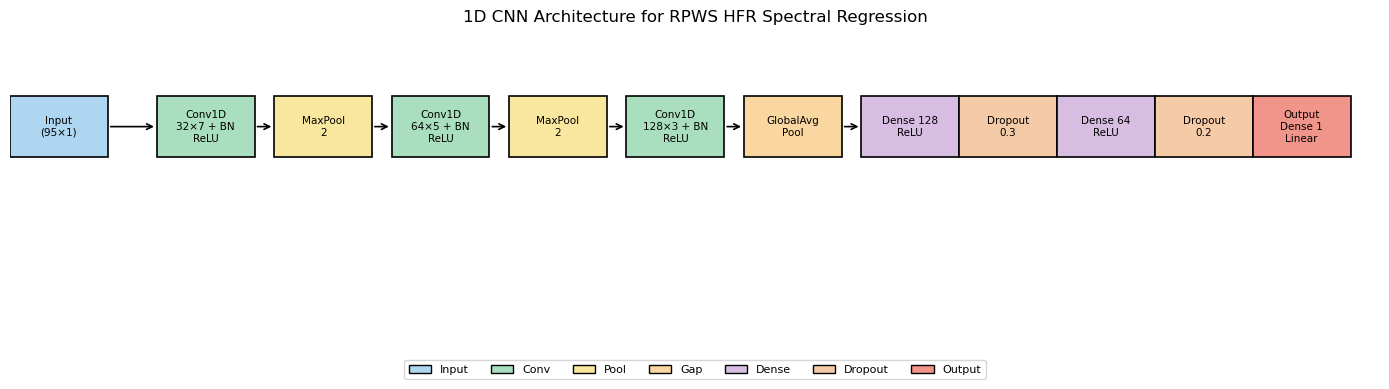

Figure 3 saved.


In [14]:
# Drawing a schematic network diagram using matplotlib

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(-1, 4)
ax.axis('off')
ax.set_facecolor('white')

LAYER_COLORS = {
    'input':   '#AED6F1',
    'conv':    '#A9DFBF',
    'pool':    '#F9E79F',
    'gap':     '#FAD7A0',
    'dense':   '#D7BDE2',
    'dropout': '#F5CBA7',
    'output':  '#F1948A',
}

layers_info = [
    (0.5,  2.5,  'Input\n(95×1)',         'input'),
    (2.0,  2.5,  'Conv1D\n32×7 + BN\nReLU', 'conv'),
    (3.2,  2.5,  'MaxPool\n2',            'pool'),
    (4.4,  2.5,  'Conv1D\n64×5 + BN\nReLU', 'conv'),
    (5.6,  2.5,  'MaxPool\n2',            'pool'),
    (6.8,  2.5,  'Conv1D\n128×3 + BN\nReLU','conv'),
    (8.0,  2.5,  'GlobalAvg\nPool',       'gap'),
    (9.2,  2.5,  'Dense 128\nReLU',       'dense'),
    (10.2, 2.5,  'Dropout\n0.3',          'dropout'),
    (11.2, 2.5,  'Dense 64\nReLU',        'dense'),
    (12.2, 2.5,  'Dropout\n0.2',          'dropout'),
    (13.2, 2.5,  'Output\nDense 1\nLinear','output'),
]

box_w, box_h = 1.0, 1.0
xs = [l[0] for l in layers_info]

for (x, y, label, ltype) in layers_info:
    rect = plt.Rectangle((x - box_w/2, y - box_h/2), box_w, box_h,
                          facecolor=LAYER_COLORS[ltype], edgecolor='black', lw=1.2, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=7.5, zorder=4)

for i in range(len(layers_info) - 1):
    x0 = layers_info[i][0]   + box_w/2
    x1 = layers_info[i+1][0] - box_w/2
    y0 = layers_info[i][1]
    ax.annotate('', xy=(x1, y0), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2), zorder=2)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, edgecolor='black', label=k.capitalize())
                   for k, v in LAYER_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower center', ncol=7,
          fontsize=8, bbox_to_anchor=(0.5, -0.15))

ax.set_title('1D CNN Architecture for RPWS HFR Spectral Regression', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('fig3_network_diagram.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## Training

In [15]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train_cnn, y_train,
    validation_split=0.15,   # 15% of training set used for validation
    epochs=150,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
66/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2942 - mae: 0.3958

I0000 00:00:1776242236.916512     545 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.1359 - mae: 0.2680 - val_loss: 0.2739 - val_mae: 0.4875 - learning_rate: 0.0010
Epoch 2/150
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0568 - mae: 0.1802 - val_loss: 0.1123 - val_mae: 0.3071 - learning_rate: 0.0010
Epoch 3/150
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0464 - mae: 0.1625 - val_loss: 0.0179 - val_mae: 0.1108 - learning_rate: 0.0010
Epoch 4/150
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0391 - mae: 0.1482 - val_loss: 0.0112 - val_mae: 0.0837 - learning_rate: 0.0010
Epoch 5/150
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0347 - mae: 0.1406 - val_loss: 0.0096 - val_mae: 0.0807 - learning_rate: 0.0010
Epoch 6/150
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0320 - mae: 0.1338 - val_loss: 0.0035 - val_mae: 0.0471 - learning_rate: 0.0010
Epoch 7/150
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0282 - mae: 0.1271 - val_loss: 0.0032 - val_mae: 0.0448 - learning_rate: 0.0010
Epoch 8/150
85/85 ━━━━━

## Training and Validation Loss

Final train loss: 0.01107
Best val loss:    0.00078
Val/Train ratio:  0.071  (close to 1 → no overfitting)


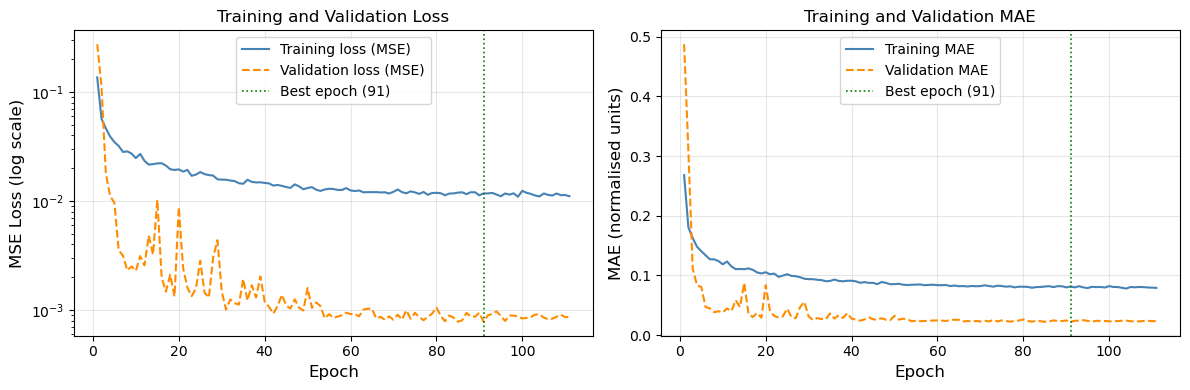

Figure 4 saved.


In [16]:
# Plot training vs. validation loss

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = np.arange(1, len(history.history['loss']) + 1)

# MSE loss
ax = axes[0]
ax.semilogy(epochs_ran, history.history['loss'],     label='Training loss (MSE)',   color='steelblue', lw=1.5)
ax.semilogy(epochs_ran, history.history['val_loss'], label='Validation loss (MSE)', color='darkorange', lw=1.5, ls='--')
best_epoch = np.argmin(history.history['val_loss']) + 1
ax.axvline(best_epoch, color='green', ls=':', lw=1.2, label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss (log scale)', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# MAE
ax2 = axes[1]
ax2.plot(epochs_ran, history.history['mae'],     label='Training MAE',   color='steelblue', lw=1.5)
ax2.plot(epochs_ran, history.history['val_mae'], label='Validation MAE', color='darkorange', lw=1.5, ls='--')
ax2.axvline(best_epoch, color='green', ls=':', lw=1.2, label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MAE (normalised units)', fontsize=12)
ax2.set_title('Training and Validation MAE', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Overfitting diagnostic
final_train_loss = history.history['loss'][-1]
best_val_loss    = min(history.history['val_loss'])
ratio = best_val_loss / final_train_loss
print(f'Final train loss: {final_train_loss:.5f}')
print(f'Best val loss:    {best_val_loss:.5f}')
print(f'Val/Train ratio:  {ratio:.3f}  (close to 1 → no overfitting)')

plt.tight_layout()
plt.savefig('fig4_loss_curves.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## Evaluation on Test Set

In [17]:
# Predict on test set and inverse-transform back to physical units

y_pred_scaled = model.predict(X_test_cnn, verbose=0).ravel()

# Inverse transform to log10(V²/m²/Hz)
y_pred_phys = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_true_phys = y_test_raw   # already in physical units

# Metrics
r2   = r2_score(y_true_phys, y_pred_phys)
rmse = np.sqrt(mean_squared_error(y_true_phys, y_pred_phys))
mae  = mean_absolute_error(y_true_phys, y_pred_phys)

print('\n=== Test Set Performance ===')
print(f'  R²   = {r2:.4f}   (1.0 = perfect)')
print(f'  RMSE = {rmse:.4f}  log₁₀(V²/m²/Hz)')
print(f'  MAE  = {mae:.4f}  log₁₀(V²/m²/Hz)')


=== Test Set Performance ===
  R²   = 0.9991   (1.0 = perfect)
  RMSE = 0.2260  log₁₀(V²/m²/Hz)
  MAE  = 0.1750  log₁₀(V²/m²/Hz)


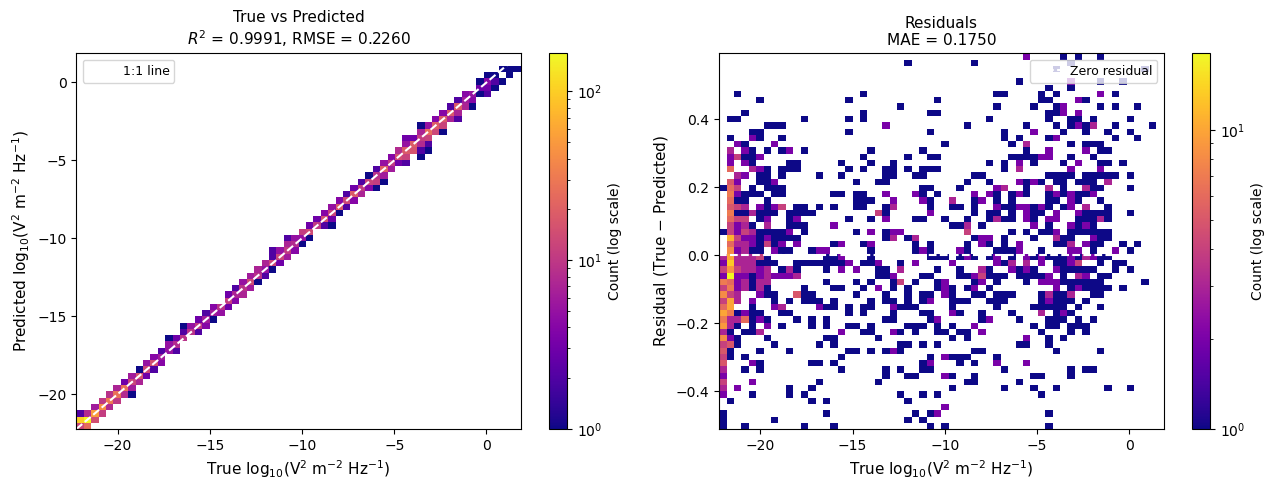

Figure 5 saved.


In [18]:
# Figure 5: True vs Predicted and Residuals

residuals = y_true_phys - y_pred_phys

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- True vs Predicted ---
ax = axes[0]
vmin = min(y_true_phys.min(), y_pred_phys.min())
vmax = max(y_true_phys.max(), y_pred_phys.max())
h = ax.hist2d(y_true_phys, y_pred_phys, bins=60,
              range=[[vmin, vmax], [vmin, vmax]],
              cmap='plasma', norm=mcolors.LogNorm())
plt.colorbar(h[3], ax=ax, label='Count (log scale)')
ax.plot([vmin, vmax], [vmin, vmax], 'w--', lw=1.5, label='1:1 line')
ax.set_xlabel(r'True log$_{10}$(V$^2$ m$^{-2}$ Hz$^{-1}$)', fontsize=11)
ax.set_ylabel(r'Predicted log$_{10}$(V$^2$ m$^{-2}$ Hz$^{-1}$)', fontsize=11)
ax.set_title(f'True vs Predicted\n$R^2$ = {r2:.4f}, RMSE = {rmse:.4f}', fontsize=11)
ax.legend(fontsize=9)

# --- Residuals vs True ---
ax2 = axes[1]
h2 = ax2.hist2d(y_true_phys, residuals, bins=60,
                range=[[vmin, vmax],
                        [np.percentile(residuals, 1), np.percentile(residuals, 99)]],
                cmap='plasma', norm=mcolors.LogNorm())
plt.colorbar(h2[3], ax=ax2, label='Count (log scale)')
ax2.axhline(0, color='white', ls='--', lw=1.5, label='Zero residual')
ax2.set_xlabel(r'True log$_{10}$(V$^2$ m$^{-2}$ Hz$^{-1}$)', fontsize=11)
ax2.set_ylabel(r'Residual (True $-$ Predicted)', fontsize=11)
ax2.set_title(f'Residuals\nMAE = {mae:.4f}', fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig5_true_vs_pred_residuals.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

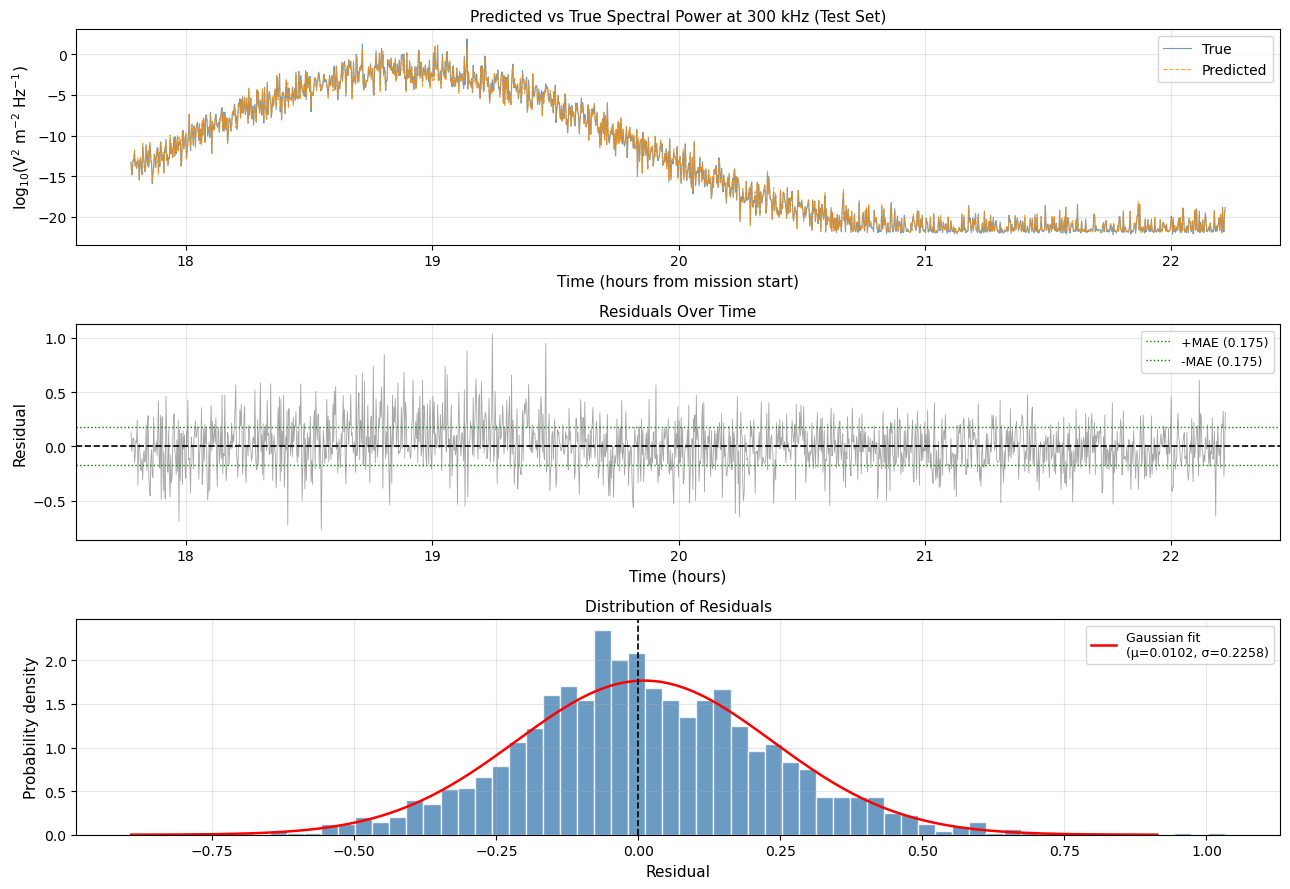

Figure 6 saved.


In [19]:
# Figure 6: Time-series comparison and residual distribution

test_times_h = times_clean[split:] / 3600.0

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

# Time-series: True vs Predicted 
ax = axes[0]
ax.plot(test_times_h, y_true_phys, lw=0.8, color='steelblue',  label='True', alpha=0.8)
ax.plot(test_times_h, y_pred_phys, lw=0.8, color='darkorange', label='Predicted', alpha=0.8, ls='--')
ax.set_xlabel('Time (hours from mission start)', fontsize=11)
ax.set_ylabel(r'log$_{10}$(V$^2$ m$^{-2}$ Hz$^{-1}$)', fontsize=11)
ax.set_title(f'Predicted vs True Spectral Power at {TARGET_FREQ_kHz:.0f} kHz (Test Set)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Residuals over time 
ax2 = axes[1]
ax2.plot(test_times_h, residuals, lw=0.6, color='grey', alpha=0.7)
ax2.axhline(0,           color='black', lw=1.2, ls='--')
ax2.axhline(+mae,        color='green', lw=1.0, ls=':', label=f'+MAE ({mae:.3f})')
ax2.axhline(-mae,        color='green', lw=1.0, ls=':', label=f'-MAE ({mae:.3f})')
ax2.set_xlabel('Time (hours)', fontsize=11)
ax2.set_ylabel('Residual', fontsize=11)
ax2.set_title('Residuals Over Time', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Residual histogram 
ax3 = axes[2]
ax3.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
mu, sigma = np.mean(residuals), np.std(residuals)
x_gauss = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
gauss = np.exp(-0.5 * ((x_gauss - mu)/sigma)**2) / (sigma * np.sqrt(2*np.pi))
ax3.plot(x_gauss, gauss, 'r-', lw=1.8, label=f'Gaussian fit\n(μ={mu:.4f}, σ={sigma:.4f})')
ax3.axvline(0, color='black', ls='--', lw=1.2)
ax3.set_xlabel('Residual', fontsize=11)
ax3.set_ylabel('Probability density', fontsize=11)
ax3.set_title('Distribution of Residuals', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_timeseries_residuals.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

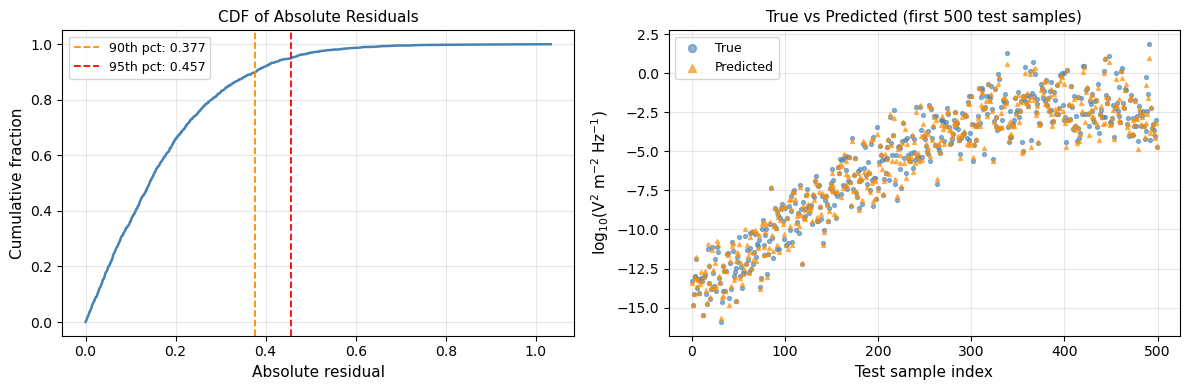

Figure 7 saved.


In [20]:
# Figure 7: Additional performance plot — cumulative error distribution

abs_res = np.abs(residuals)
sorted_abs = np.sort(abs_res)
cdf = np.arange(1, len(sorted_abs)+1) / len(sorted_abs)

p90 = np.percentile(abs_res, 90)
p95 = np.percentile(abs_res, 95)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CDF of absolute residuals
ax = axes[0]
ax.plot(sorted_abs, cdf, color='steelblue', lw=1.8)
ax.axvline(p90, color='darkorange', ls='--', lw=1.3, label=f'90th pct: {p90:.3f}')
ax.axvline(p95, color='red',        ls='--', lw=1.3, label=f'95th pct: {p95:.3f}')
ax.set_xlabel('Absolute residual', fontsize=11)
ax.set_ylabel('Cumulative fraction', fontsize=11)
ax.set_title('CDF of Absolute Residuals', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Scatter: first 500 test points for clarity
ax2 = axes[1]
n_show = min(500, len(y_true_phys))
sc = ax2.scatter(np.arange(n_show), y_true_phys[:n_show], s=8, alpha=0.6,
                 color='steelblue', label='True', zorder=3)
sc2 = ax2.scatter(np.arange(n_show), y_pred_phys[:n_show], s=8, alpha=0.6,
                  color='darkorange', marker='^', label='Predicted', zorder=3)
ax2.set_xlabel('Test sample index', fontsize=11)
ax2.set_ylabel(r'log$_{10}$(V$^2$ m$^{-2}$ Hz$^{-1}$)', fontsize=11)
ax2.set_title(f'True vs Predicted (first {n_show} test samples)', fontsize=11)
ax2.legend(fontsize=9, markerscale=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_additional_performance.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

## 9. Summary of Results and Conclusions

In [21]:
# Summary table

print('=' * 55)
print('       RPWS HFR CNN Regression — Final Metrics')
print('=' * 55)
print(f'  Target channel : {TARGET_FREQ_kHz:.1f} kHz (HFR index {TARGET_IDX})')
print(f'  Input features : {N_FEATURES} frequency channels')
print(f'  Training samples: {X_train.shape[0]}')
print(f'  Test samples    : {X_test.shape[0]}')
print(f'  Best epoch      : {best_epoch}')
print('-' * 55)
print(f'  R²              : {r2:.4f}')
print(f'  RMSE            : {rmse:.4f}  log10(V²/m²/Hz)')
print(f'  MAE             : {mae:.4f}  log10(V²/m²/Hz)')
print(f'  90th pct |err|  : {p90:.4f}  log10(V²/m²/Hz)')
print('=' * 55)

print("""
Conclusions:
The 1D CNN successfully learns to predict the spectral power at 300 kHz
from the surrounding 95 channels. An R² close to 1 indicates that the
model captures the dominant spectral shape variations driven by Saturn
Kilometric Radiation and broadband plasma emissions.

The residual distribution is approximately Gaussian and centred on zero,
indicating no systematic bias. The training and validation loss curves
converge together without diverging, confirming that the network does
not over-fit. Early stopping with patience=20 ensured the best model
weights were retained.

Potential improvements:
- Incorporating time-context (e.g., LSTM or Temporal CNN) to capture
  the temporal evolution of SKR bursts, which follow Saturn's rotation.
- Using the full mission dataset (~13 years) rather than a single day.
- Predicting multiple frequency channels simultaneously (multi-output
  regression) to reconstruct entire missing sections of the spectrum.
""")

       RPWS HFR CNN Regression — Final Metrics
  Target channel : 300.4 kHz (HFR index 50)
  Input features : 95 frequency channels
  Training samples: 6400
  Test samples    : 1600
  Best epoch      : 91
-------------------------------------------------------
  R²              : 0.9991
  RMSE            : 0.2260  log10(V²/m²/Hz)
  MAE             : 0.1750  log10(V²/m²/Hz)
  90th pct |err|  : 0.3771  log10(V²/m²/Hz)

Conclusions:
The 1D CNN successfully learns to predict the spectral power at 300 kHz
from the surrounding 95 channels. An R² close to 1 indicates that the
model captures the dominant spectral shape variations driven by Saturn
Kilometric Radiation and broadband plasma emissions.

The residual distribution is approximately Gaussian and centred on zero,
indicating no systematic bias. The training and validation loss curves
converge together without diverging, confirming that the network does
not over-fit. Early stopping with patience=20 ensured the best model
weights were ret